In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline


In [2]:
df = pd.read_csv("../data/raw/healthcare_data.csv")

In [3]:
df.head()

,Gender,Age,Smoker,Disease,Recommended_Treatment
0,Male,78,Yes,Diabetes,Insulin Therapy
1,Female,38,Yes,Diabetes,Insulin Therapy
2,Male,49,No,NaN,General Wellness Program
3,Male,40,No,NaN,General Wellness Program
4,Male,50,No,Heart Disease,Aspirin Therapy


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 5 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   Gender                 500 non-null    object
 1   Age                    500 non-null    int64 
 2   Smoker                 500 non-null    object
 3   Disease                394 non-null    object
 4   Recommended_Treatment  500 non-null    object
dtypes: int64(1), object(4)
memory usage: 19.7+ KB


In [5]:
df.shape

(500, 5)

In [6]:
df.isnull().sum()

Gender                     0
Age                        0
Smoker                     0
Disease                  106
Recommended_Treatment      0
dtype: int64

In [7]:
df.describe

<bound method NDFrame.describe of      Gender  Age Smoker        Disease     Recommended_Treatment
0      Male   78    Yes       Diabetes           Insulin Therapy
1    Female   38    Yes       Diabetes           Insulin Therapy
2      Male   49     No            NaN  General Wellness Program
3      Male   40     No            NaN  General Wellness Program
4      Male   50     No  Heart Disease           Aspirin Therapy
..      ...  ...    ...            ...                       ...
495    Male   78     No  Heart Disease           Aspirin Therapy
496    Male   23    Yes         Asthma         Inhaler Treatment
497  Female   35    Yes       Diabetes           Insulin Therapy
498    Male   68     No  Heart Disease           Aspirin Therapy
499  Female   22    Yes  Heart Disease           Aspirin Therapy

[500 rows x 5 columns]>

In [8]:
missing = df.isnull().sum()
missing = missing[missing>0]
print(missing)

Disease    106
dtype: int64


In [9]:
for col in df.columns:
    if df[col].isnull().sum() > 0:
        if df[col].dtype == 'object':
            df[col] = df[col].fillna(df[col].mode()[0])
        else:
            df[col] = df[col].fillna(df[col].median())

In [10]:
df.isnull().sum()

Gender                   0
Age                      0
Smoker                   0
Disease                  0
Recommended_Treatment    0
dtype: int64

In [11]:
categorical_cols = df.select_dtypes(include='object').columns
numerical_cols = df.select_dtypes(include=np.number).columns

#Visualization

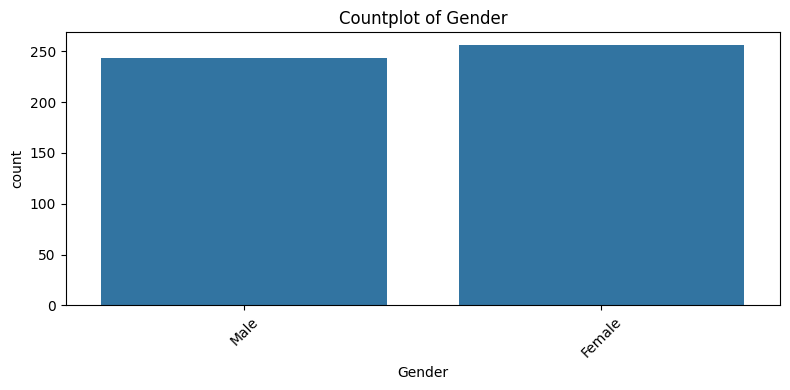

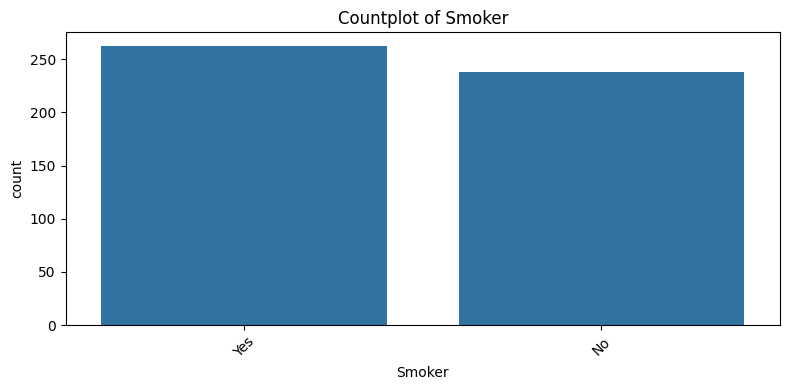

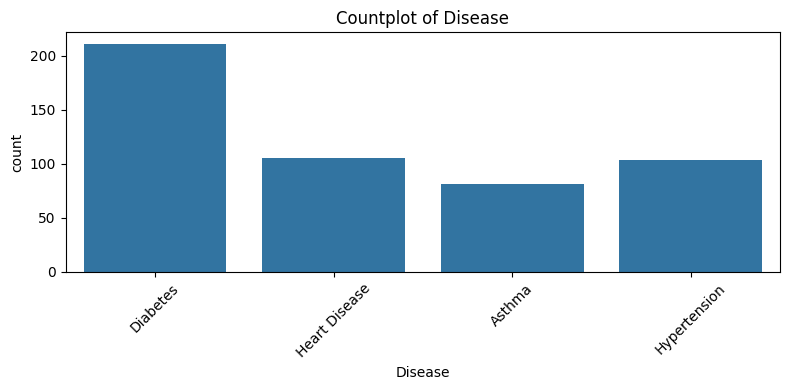

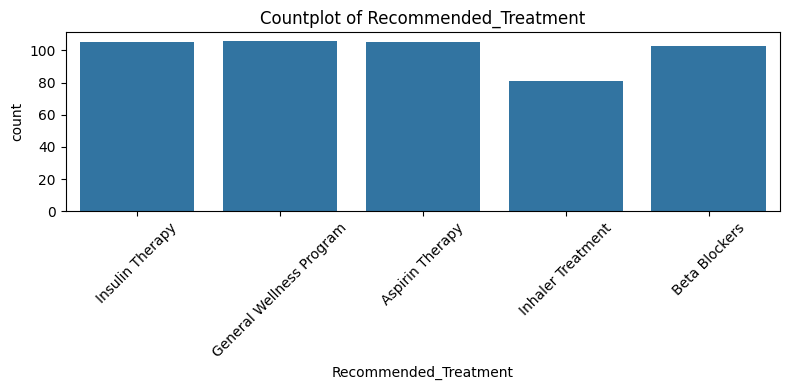

In [12]:
for col in categorical_cols:
    plt.figure(figsize=(8, 4))
    sns.countplot(data=df, x=col)
    plt.title(f"Countplot of {col}")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

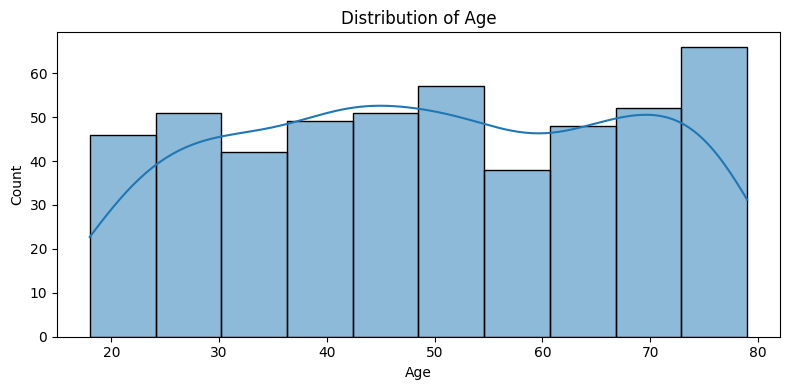

In [13]:
for col in numerical_cols:
    plt.figure(figsize=(8, 4))
    sns.histplot(df[col], kde=True)
    plt.title(f"Distribution of {col}")
    plt.tight_layout()
    plt.show()

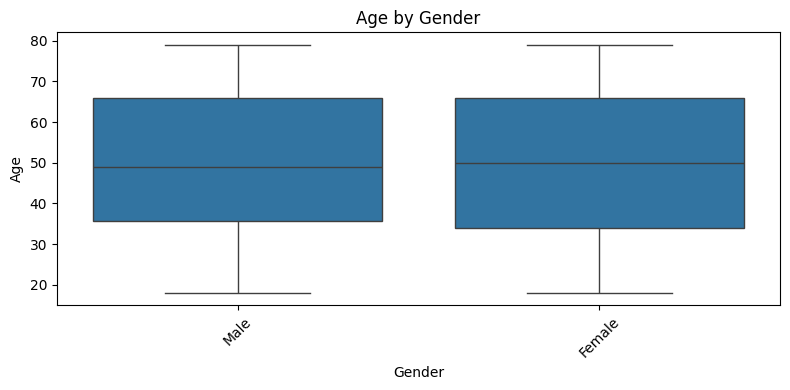

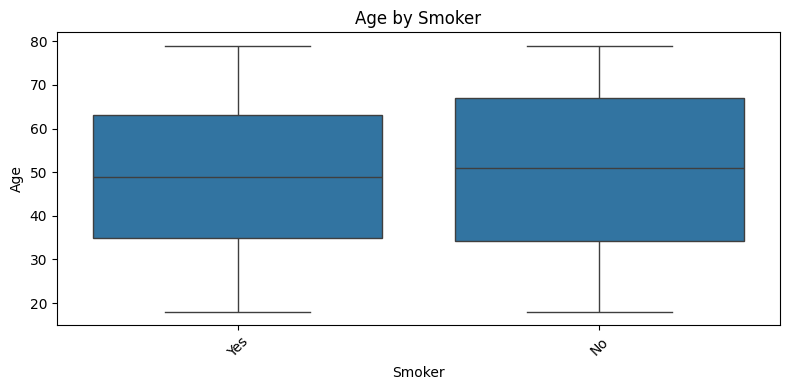

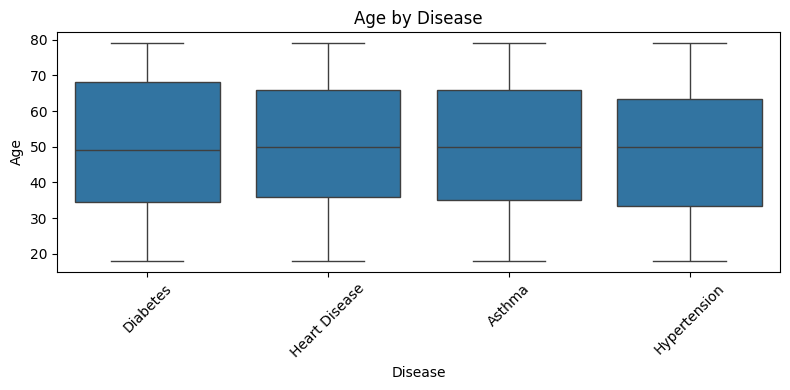

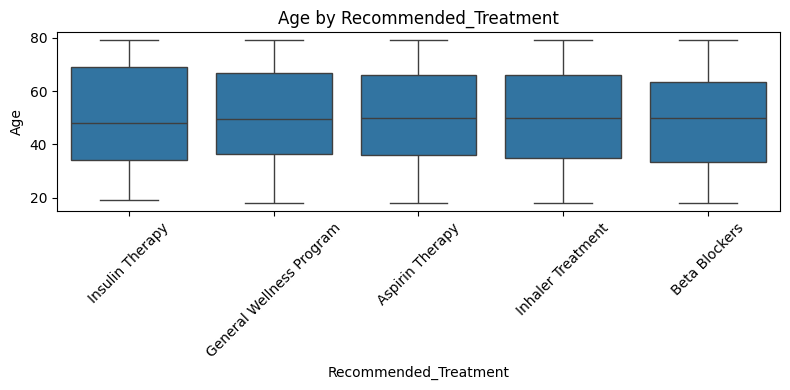

In [14]:
for cat_col in categorical_cols:
    for num_col in numerical_cols:
        plt.figure(figsize=(8, 4))
        sns.boxplot(x=cat_col, y=num_col, data=df)
        plt.title(f"{num_col} by {cat_col}")
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()